# 20_异常值处理方法-标准差法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本小节给大家一步一步讲清楚异常值处理方法方面的标准差法\~

首先，聊聊异常值\~

### 什么是“异常值”？

异常值就像“考场里出格的学生”。班上大多数人考试都考了 **80\~90分**，突然有个人考了**20分**或者**满分100分**，那你会觉得：“哎？这分数好像不太正常”。

这些远离大多数人的值，就叫**异常值**（outliers）。

### 什么是“标准差法”？

“标准差法”就是用一种数学的“刻度尺”，**标准差**，来测量一个数值**离平均水平有多远**。

我们先来看个日常生活的比喻：

- 平均水平就像班级平均分；
- 标准差就像大家的“分散程度”；
- 如果某个人的分数离平均分非常远，就像站得离人群很远——那他可能就是个“异常”。

> **标准差法**就是：  
> 用“均值 ± k × 标准差”来设定一个“合理的范围”，  
> 超出这个范围的值，就认为是“异常值”。

### 举个简单例子

某公司10名员工的月薪如下（单位：元）：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
5000, 5200, 5100, 5300, 4900, 5150, 5050, 5000, 4950, 25000
```

- 大部分工资在5000上下。
- 但最后一个人25000元，明显偏高。

我们想判断这个25000是不是**异常值**，可以用标准差法。

## 标准差法的数学原理和公式推理

### Step 1：计算均值（平均值）

设有一组数据：$x_1, x_2, x_3, \dots, x_n$

**平均值公式：**


$$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$$


也就是把所有数加起来除以数量。

### Step 2：计算标准差（standard deviation）

**标准差公式（总体标准差）：**


$$
\sigma = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2 }
$$


意思是：

- 每个数和平均数的差（离差）平方；
- 求出所有平方后的平均值；
- 然后再开方。

这是衡量“波动有多大”的标准。

### Step 3：设定“合理范围”（异常值判断边界）

我们认为正常值应该落在以下区间中：


$$
[\mu - k\sigma,\ \mu + k\sigma]
$$


其中：

- $k$ 是一个你自己设定的常数，一般取：
- **k = 2**：数据超过2个标准差就认为是异常（适用于近似正态分布的数据）
- **k = 3**：更严格的筛选，偏离3个标准差才叫异常

### Step 4：判断是否异常

只要某个数据 $x_i$ 满足以下条件：


$$
|x_i - \mu| > k\sigma
$$


就可以认定它是异常值。

### 为什么标准差法有效？

它基于一个很重要的统计现象：

> **在正态分布中：**

- 约 **68.3%** 的数据在 ±1σ 以内
- 约 **95.4%** 的数据在 ±2σ 以内
- 约 **99.7%** 的数据在 ±3σ 以内

所以：

- 落在 ±2σ 外的数据只有不到5%，可认为“不正常”
- ±3σ外的数据更罕见，可视为极端异常

### 算法流程

我们一步一步梳理整个标准差法的操作流程：

**输入**：一组数值数据 $x_1, x_2, ..., x_n$

**步骤1**：计算平均值 $\mu$


$$
\mu = \frac{1}{n} \sum_{i=1}^{n} x_i
$$


**步骤2**：计算标准差 $\sigma$


$$
\sigma = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2 }
$$


**步骤3**：设定阈值常数 $k$（一般取2或3）

**步骤4**：判断每个数据点是否为异常

对每个数据 $x_i$：

1. 计算离均差的绝对值 $|x_i - \mu|$
2. 如果：


$$
|x_i - \mu| > k \cdot \sigma
$$


则 $x_i$ 是异常值。

**输出**：

- 异常值的列表
- 或者标记哪些数据是异常的

总的来看，**标准差法**是通过判断一个数**偏离平均值的程度（以标准差为单位）**，来发现异常值的。

若偏离太多（大于k倍标准差），就认为它是“离群值”或“异常数据”。

## 完整案例

假设咱们需要分析某公司每天的产品销量。你观察到一些天的销量远高于平时，怀疑存在异常（如录入错误、促销活动、黑客攻击等）。你打算使用标准差法检测并处理这些异常值，以便为后续的预测建模清洗数据。

### 数据集

我们使用一个**虚拟模拟但接近真实场景的销售数据集**，模拟90天内的销售记录（有意添加了几个异常值）。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置种子以保证可复现性
np.random.seed(42)

# 生成90天内的大部分销量数据：服从正态分布
normal_sales = np.random.normal(loc=200, scale=20, size=85)  # 平均200件，波动范围20件

# 人为插入5个异常数据（远大于平均水平）
outliers = np.array([400, 420, 390, 450, 480])

# 合并数据
sales_data = np.concatenate((normal_sales, outliers))

# 构造DataFrame，添加日期
dates = pd.date_range(start='2025-01-01', periods=90)
df = pd.DataFrame({'Date': dates, 'Sales': sales_data})

# 打乱数据顺序（模拟真实场景）
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,Date,Sales
0,2025-02-05,175.583127
1,2025-01-07,231.584256
2,2025-03-22,195.606562
3,2025-03-05,176.075868
4,2025-01-14,161.734395


### 初步可视化（了解数据形态）

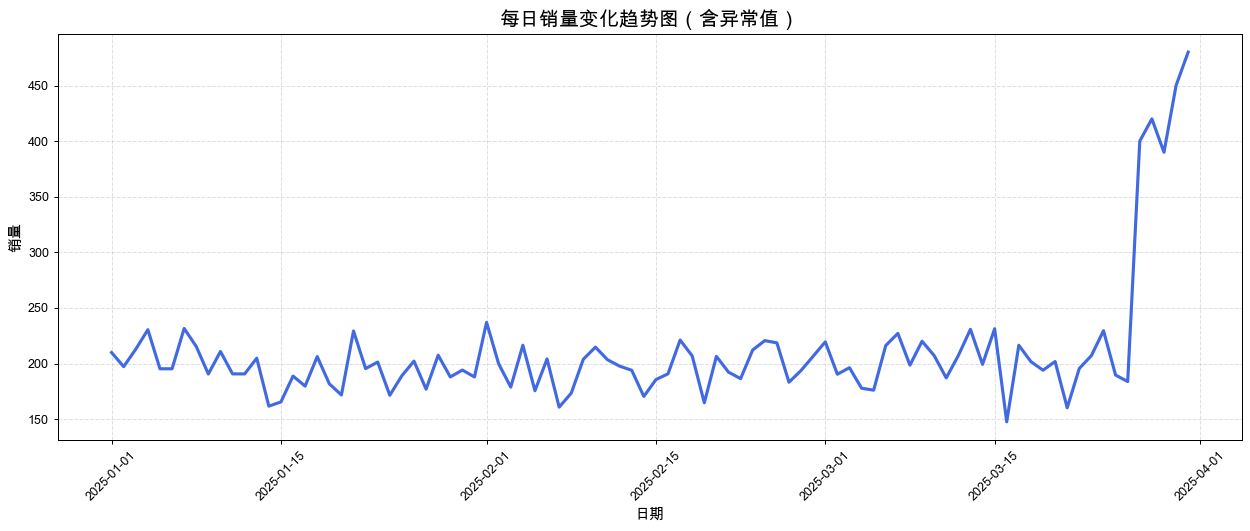

In [3]:
plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Sales', data=df, color='royalblue', linewidth=2.5)
plt.title('每日销量变化趋势图（含异常值）', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('销量', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

这张图会让我们一目了然地看到：

![原文参考图，当前结果见代码输出](attachments/img_001.png)

- 大部分销量集中在某一稳定区间（约在1000上下）
- 但部分点数值非常高（400\~480），明显是异常值

### 使用标准差法检测异常值

**计算均值与标准差**

In [4]:
mean_sales = df['Sales'].mean()
std_sales = df['Sales'].std()

print(f"平均销量: {mean_sales:.2f}")
print(f"标准差: {std_sales:.2f}")

平均销量: 210.53
标准差: 56.71


**设置标准差阈值（通常取 2 或 3）**

In [5]:
k = 3  # 阈值倍数

# 判断哪些是异常值
df['is_outlier'] = df['Sales'].apply(lambda x: abs(x - mean_sales) > k * std_sales)

# 显示异常值数据
df[df['is_outlier']]

,Date,Sales,is_outlier
20,2025-03-30,450.0,True
23,2025-03-31,480.0,True
36,2025-03-29,390.0,True
53,2025-03-27,400.0,True
79,2025-03-28,420.0,True


### 可视化异常值检测结果

**折线图（标出异常值）**

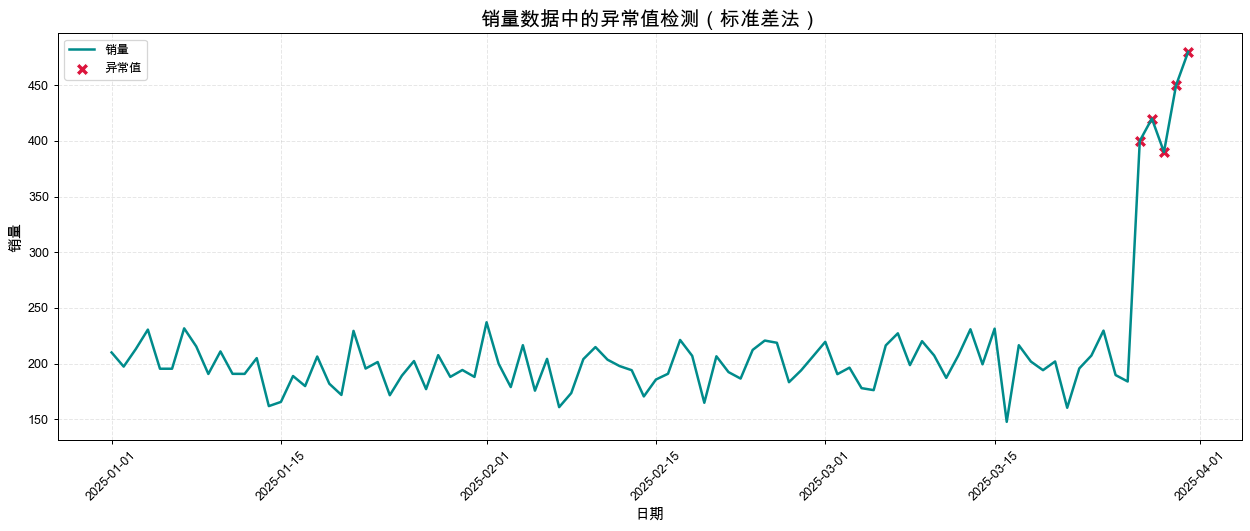

In [6]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='Date', y='Sales', label='销量', color='darkcyan', linewidth=2)
sns.scatterplot(data=df[df['is_outlier']], x='Date', y='Sales',
                label='异常值', color='crimson', s=100, marker='X')

plt.title('销量数据中的异常值检测（标准差法）', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('销量', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_002.png)

**分布图 + 阈值线**

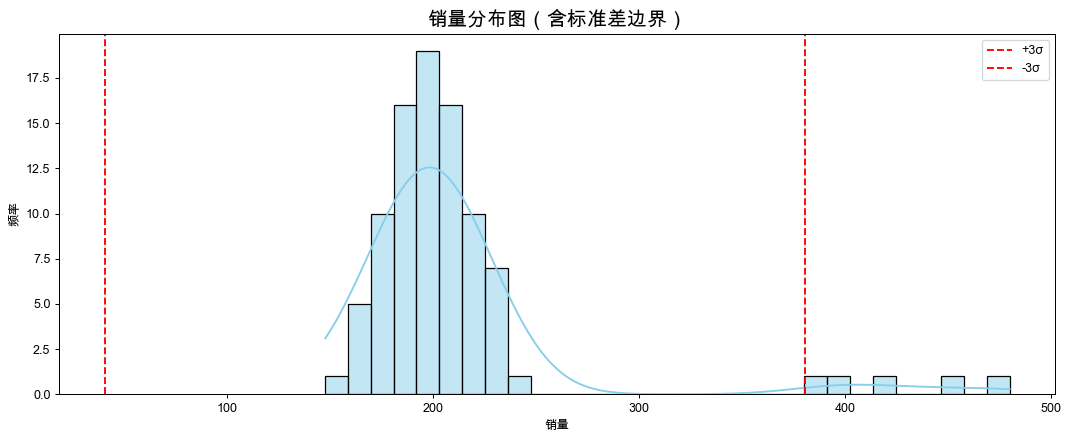

In [7]:
plt.figure(figsize=(12, 5))
sns.histplot(df['Sales'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.axvline(mean_sales + k*std_sales, color='red', linestyle='--', label='+3σ')
plt.axvline(mean_sales - k*std_sales, color='red', linestyle='--', label='-3σ')
plt.title('销量分布图（含标准差边界）', fontsize=16)
plt.xlabel('销量')
plt.ylabel('频率')
plt.legend()
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_003.png)

**Step 1：构造数据集**

使用 `np.random.normal` 构造服从正态分布的数据（大部分正常值），再手动添加一些明显偏高的异常值。

**Step 2：计算均值和标准差**

这是标准差法的核心指标。我们用 `.mean()` 和 `.std()` 分别获得它们。

**Step 3：设置阈值倍数（k）**

通常标准差法使用 ±2σ 或 ±3σ 区间，这决定了算法对异常的“敏感度”。

**Step 4：筛选异常值**

使用 lambda 函数和布尔逻辑判断 `|x - μ| > kσ` 的条件，将其标记出来。

**Step 5：可视化**

我们通过折线图标出哪些日期的销量被判定为异常，还结合直方图展示它们在分布中的位置。

## 标准差法的优点和缺点

**优点**：

1. **简单易实现**：不需要复杂建模，只需几行代码就可以执行异常检测。
2. **理论基础扎实**：基于正态分布的统计理论，适用于数据近似正态分布的场景。
3. **计算高效**：不依赖机器学习算法，对大规模数据也能快速判断。
4. **可解释性强**：检测逻辑透明，便于向业务团队解释“为什么这个点是异常”。

**缺点**：

1. **强依赖正态分布假设**：如果数据严重偏态或含有长尾分布，标准差法效果较差，此时会误判正常值为异常，或漏掉异常值。
2. **对极端异常值敏感**：异常值本身会影响均值和标准差，使得检测边界“被拉宽”，导致更多异常被“隐藏”。
3. **不能处理多维数据**：只能处理单变量异常（例如只分析销量），若有多个维度（如销量+价格+点击率），需考虑更复杂方法（如Mahalanobis距离、多变量分布等）。

### 标准差法适用的场景

**最适合场景：**

1. **数据服从或近似正态分布**：考试成绩、测量误差、人口身高、呼吸频率等。
2. **单变量异常检测**：例如检测一个指标（如日销售额）是否异常。
3. **业务期望“快而准”**：不需要复杂建模，希望快速识别明显的异常点，特别适用于**ETL数据清洗**。
4. **数据样本量较大**：可以用中心极限定理近似正态分布，增强算法可靠性。

**不适合场景**：

1. **数据分布严重偏态**（如指数分布、Poisson分布等）；
2. **样本量很小**，均值和标准差不稳定；
3. **多变量关联场景**，标准差法无力分析变量之间的关系；
4. **异常值对均值影响很大**，标准差会被拉大，掩盖真实异常。

### 如果不适用标准差法，可以考虑什么？

- **IQR法（四分位距法）**：适合偏态分布数据；
- **Z-score标准化法**：与标准差法原理类似，但适合标准化数据；
- **孤立森林（Isolation Forest）**：适用于高维数据或非线性结构；
- **DBSCAN**：基于密度的聚类方法，适合识别非规则异常群体；
- **LOF（局部离群因子）**：考虑邻域密度，非常适用于非球形分布。